# Pakiet AutoMl dla klasyfikacji wieloetykietowej dla (sekwencyjnych) danych wielowymiarowych 

In [1]:
%cd ..

/home/kakold/Desktop/AutoML/AutoML


### Grupa docelowa dla naszego pakietu

Pakiet AutoML jest skierowany dla problemu multilabel classifcation dla danych sekwencyjnych. Pakiet umożliwia wypłaszczanie danych w postaci surowej o kształcie (sekwencje,próbki,cechy). Głównym problemem, który nasz pakiet ma rozwiązywać do dostosowanie danych sekwencyjnych i istotnych zależnościach czasowych dla modeli automl. Pakiet wybiera najlepszy model spośród: XGboost w dwóch wariantach: OneVsRest oraz multioutput oraz SVC i regresje logistyczną w wariantach OneVsReat

### Dane Dla problemu

Nasz pakiet AutoML udostepnie metodą trimming data dzięki której umożliwia obróke danych postaci (sekwencje,próbki,cechy) do docelowego formatu (próbki, cechy), który odpowiada większosci znanym modelom.

Wypłaszczanie odbywa się przy pomocy okna, tj, wybieramy jego wielkość w zakresie do długości próbek najkrótszej sekwencji. Następnie iterując po każdej sekwencji akumulujemy cechy dla każdego kolejnego odcinka próbek dlugości okna tworząc nową końcową próbkę. Analogicznie procesowane są etykiey, wystąpienie klasy pozytywnej dla danego okna jest rejestrowane gdy w tym oknie było conjamniej 20% odczytów pozytywnych z tej klasy.

W ten sposób otrzymujemy wypłaszczone dane dwuwymiarowe akcpetowalne dla funkcji fit klasy AutoMlMultiLabelClassifier.

Przygotowane zostały dwa notatniki:
1. Tutorial.ipynb z przygotowanym przez nas datasetem postacji (sekwencje,próbki,cechy) wraz z przykładową obróką oknem, każda sekwencja
   to jedno nagranie, próbki to klatki z tego nagrania, a cechy to macierz liczbowa będacą wynikiem wcześniej ekstrakcji cech z nagrania.
2. Tutorial2_FlatData.ipynb z danymi synetycznymi nie wymagającymi wypłaszczania

### Przegląd szczegółowych problemów postaci (sekwencje,próbki,cechy)

##### Human Action Evaluation applied to Weightlifting

Projekt skupiał się na klasyfikowaniu błedów w wykonywaniu pewnych ćwiczeń siłowych na podstawie analizy nagrania.

Dane wejściowe dla tego problemu stanowi macierz rozmiaru (n_frames, n_features). Gdzie n_frames to liczba klatek nagrania. Na nagraniu znajduje się osoba wykonująca ćwiczenie siłowe z obciążeniem. Z tego nagrania estymowana jest sylwetka, zestaw kilkunastów punktów, następnie liczona jest macierz dystansów tych punktów. Dla dla każdej klatki wyznaczona jest to macierz dystansów - punktów jest n_features. Ostatecznie Input to omawiane macierze dystansów dla każdej klatki.

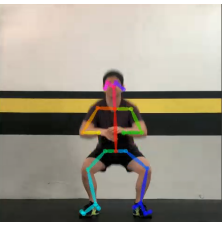

Nagranie później dzielone jest ze względu na powtórzenia. W przypadku przykładowo przysiadu ze sztangą na plecach, powtórzenie wyznaczane jest na podstawie pozycji głowy. Jeżeli pozycja głowy z punktu najwyższego, to jest startowego - czyli osoba stoi, zejdzie na dół i powróci, czyli punkt głowy wróci na pierwotną wysokość to oznacza, że powtórzyło się dokładnie jedno powtórzenie. Więc wyznaczone jest jedno powtórzenie. Każde nagranie jest dzielone następnie na powtórzenia. Te powtórzenia przypominają okna - czyli spójne podciągi danych -  w naszym problemie, z tym że okna te są różnej długości.

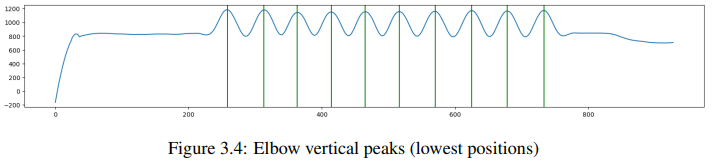

Następnie każde takie powtórzenie jest klasyfikowane. Różnica jest taka że klasyfikacja powtórzenia (okna) jest jedna liczbą, a nie jak u nas listą klas (0,1). Nasze narzędzie udostępnia możliwość klasyfikacji wielu klas dla tej samej klatki.

Rosenhaim, A. (2023). Human Action Evaluation applied to Weightlifting. Dissertação de Mestrado.
https://repositorio-aberto.up.pt/bitstream/10216/152213/2/637071.pdf#page=45&zoom=100,132,484

##### Human Activity Recognition Using Smartphones

Rozpoznawanie aktywności człowieka (HAR - Human Activity Recognition)

Dane pochodzące z akcelerometrów i żyroskopów (np. w telefonach komórkowych lub opaskach fitness).
Typowy format danych to macierz (n_frames, n_features), gdzie n_features to liczba kanałów (np. akcelerometr x, y, z). Tworzą zatem dla odpowiednie wejście.


Dzieli się dane na okna (np. co 2 sekundy).
Każde okno jest klasyfikowane jako jedna z aktywności (np. chodzenie, bieganie, siedzenie).

Różni się jednak wyjściem, tutaj istnieje tylko klasyfikacja pojedyńcza. U nas jednak celem jest wielokrotna klasyfikacja.

Reyes-Ortiz, J., Anguita, D., Ghio, A., Oneto, L., & Parra, X. (2013). Human Activity Recognition Using Smartphones [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C54S4K.

# Ładowaie danych

In [2]:
from python_files.Preprocess import load_pickle_file
import numpy as np
import pandas as pd

data = load_pickle_file('./data/data.pkl')

2025-01-19 19:27:20.748078: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-19 19:27:20.751284: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-19 19:27:20.761581: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737311240.780372   92945 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737311240.785952   92945 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-19 19:27:20.804276: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

Dane wczytane z pliku './data/data.pkl'.


In [3]:
from python_files.automl import AutoMlMultiLabelClassifier
from sklearn.model_selection import train_test_split
from skmultilearn.model_selection import iterative_train_test_split

# X = data['X']
# y = data['y']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

/home/kakold/anaconda3/envs/hot/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


# Model

### Przygotowanie danych

In [4]:
# Podajemy nazwę dla każdej klasy. Gdy nic nie podamy, używane będą domyślne nazwy f"class_{i}".
labels_type = [
    "Squat-depth" ,
    "Back-round" ,
    "Taking-off-foot",
    "Knee-collapse" ,
    "Butt-wink" ,
    "Dominant-hip" ,
    "Lack-of-abdominal-tension",
    "No-knee-outlet",
    "Bad-head-movement",
    "Back-warped"
]
labels_type = [labels_type[i] for i in [0, 1, 2, 3, 5, 7]]

In [5]:
# Inicjalizacja Pakietu
cls = AutoMlMultiLabelClassifier(labels_type=labels_type)

X = data['X']
y = data['y']
y = [arr[:, [0, 1, 2, 3, 5, 7]] for arr in y]

# Opcjonalne Wypłaszczenie danych
# fraction to jakas czesc mozliwego okna uzyc jako okna faktycznego. Sufit(1.0) to długość najmniejszej sekwencji
X,y = cls.trimming_data(X,y, fraction = 0.2)
X_train, y_train, X_test, y_test = iterative_train_test_split((X),(y), test_size=0.2)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Selekcja i Optymalizacja Modelu

In [ ]:
# Selekcja i optymalizacja modelu
# Wyświetlane są trenowane modele
# Ranking modeli względem wybranej metryki do optymalizacji
# Parametry najlepszego modelu
# Statystki na zbiorze testowym

print(X_train.shape, y_train.shape)

cls.fit(X_train, y_train)

(4636, 3264) (4636, 6)
---------------------------------------------------
Training model: OneVsRest_LogisticRegression


2025-01-19 19:27:24.960506: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-19 19:27:24.963920: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-19 19:27:24.974040: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1737311244.992498   92985 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1737311244.997552   92985 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-19 19:27:25.002199: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be

### Predykcja

In [ ]:
predictions = cls.predict(X_test)

### Wyniki modelu

In [ ]:
# Obliczamy statystki dla danych (X_test, y_test)
accuracy = cls.score(X_test, y_test)
print("accuracy: ", accuracy)

## Ewaluacja

### Raport o rozkładzie klas w danych

In [ ]:
# Raport o rozkładzie etykie w danych
cls.raport_data(X, y)

In [ ]:
# Raport o rozkładzie etykie w danych
cls.raport_data(X_train, y_train)

In [ ]:
# Raport o rozkładzie etykie w danych
cls.raport_data(X_test, y_test)

### Tworzenie raportu o wynikach modelu

In [ ]:
# Raport z wyników, dla zestawu danych (X_test, y_test)
cls.raport_scores(X_test, y_test)

# AutoSklearn for multilabel classification

In [ ]:
import numpy as np
from pprint import pprint

import sklearn.metrics
from sklearn.utils.multiclass import type_of_target

import autosklearn.classification

In [ ]:

# Using type of target is a good way to make sure your data
# is properly formatted
print(f"type_of_target={type_of_target(y)}")

# X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
#     X, y, random_state=1
# )
from sklearn.decomposition import PCA

# Reduce dimensions if needed
pca = PCA(n_components=50)  # dane są za duże wymagają redukcji
X_train = pca.fit_transform(X_train)

In [ ]:

automl = autosklearn.classification.AutoSklearnClassifier(
    time_left_for_this_task=120,
    per_run_time_limit=30,
    # Bellow two flags are provided to speed up calculations
    # Not recommended for a real implementation
    initial_configurations_via_metalearning=0,
    smac_scenario_args={"runcount_limit": 1},
)
automl.fit(X_train, y_train)

In [ ]:
print(automl.leaderboard())

In [ ]:
print(automl.sprint_statistics())

In [ ]:
X_test = pca.fit_transform(X_test)
predictions = automl.predict(X_test)
from sklearn.metrics import recall_score
# Calculate recall score
recall = recall_score(y_test, predictions, average='macro')  # or 'micro' or 'weighted' depending on your needs
print("Recall score:", recall)